   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 76.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 384.7/384.7 kB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 76.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 88.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.1/86.1 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.3/72.3 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 64.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.2/194.2 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.4/79.4 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 75.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 307.5/307.5 kB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.5/83.5 

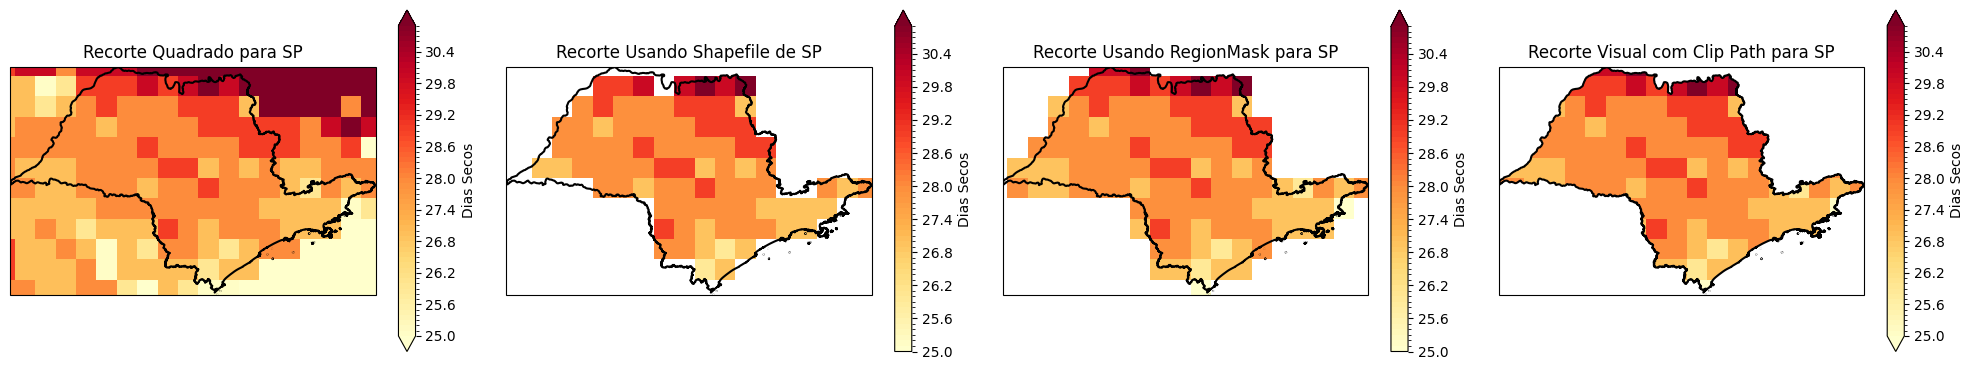

In [1]:
#=========================================================================================================================#
#                                          INSTALAÇÃO E IMPORTAÇÃO DAS BIBLIOTECAS
#=========================================================================================================================#
# instala bibliotecas
!pip install -q xarray dask netCDF4 bottleneck xclim ultraplot cartopy salem rasterio pyproj geopandas regionmask rioxarray

# importa bibliotecas
import xarray as xr
import xclim as xc
import ultraplot as uplt
import salem
import os
import cartopy.io.shapereader as shpreader
import cartopy.crs as ccrs
import numpy as np
from dask.diagnostics import ProgressBar
from matplotlib.ticker import FormatStrFormatter
import matplotlib.pyplot as plt
import regionmask
import geopandas as gpd
import rioxarray
from shapely.geometry import mapping

from cartopy.mpl.patch import geos_to_path
from matplotlib.path import Path
from matplotlib.patches import PathPatch

import warnings
warnings.filterwarnings("ignore")

#=========================================================================================================================#
#                                  DEFINE OS LIMITES DO BRASIL OU ESTADO DE SÃO PAULO
#=========================================================================================================================#
# limites
lonmin_sp, lonmax_sp, latmin_sp, latmax_sp = -53.3, -43.9, -25.4, -19.7 # estado de SP
lonmin_br, lonmax_br, latmin_br, latmax_br = -75.0, -33.0, -35.0, 7.0 # Brasil

# leitura shapefiles
shapefile_sp = salem.read_shapefile('https://github.com/evmpython/shapefile/raw/main/UFs/SP/SP_UF_2019.shp') # estado de SP
shapefile_br = salem.read_shapefile('https://github.com/evmpython/shapefile/raw/main/brasil/BRAZIL.shp') # Brasil

#=========================================================================================================================#
#                                            BAIXANDO NETCDF DO GITHUB
#=========================================================================================================================#
# define the URL for the NetCDF file
nc_url = "https://github.com/evmpython/mascarar_regiao/raw/main/dry_days_cpc_2024-08-01_2024-08-31.nc"
local_filename = "dry_days_cpc_2024-08-01_2024-08-31.nc"

# download the file to a temporary location
!wget -q $nc_url -O $local_filename

# Oabre o dataset
ds = xr.open_dataset(local_filename)

# recorta para SP
ds_sp = ds.sel(lon=slice(lonmin_sp, lonmax_sp), lat=slice(latmin_sp, latmax_sp))

#=========================================================================================================================#
#                                                  PLOTA FIGURA
#=========================================================================================================================#
#-----------------------------------------------------#
#               DEFINIÇÕES INICIAIS
#-----------------------------------------------------#
# cria figuras
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(20,3.8), subplot_kw={'projection': ccrs.PlateCarree()})

# shapefile do Estado de SP
shapefile_plot_sp = list(shpreader.Reader('https://github.com/evmpython/shapefile/raw/main/UFs/SP/SP_UF_2019.shp').geometries())

# Isso é importante porque o NetCDF usa lon/lat e o Cartopy também vai plotar em PlateCarree.
shapefile_sp = shapefile_sp.to_crs("EPSG:4326") # Pois os dois tem que se conversar

#-----------------------------------------------------#
#            FIG 1: Recorte quadrado
#-----------------------------------------------------#
# plota mapa
plot1 = ds_sp['precip'].plot(cmap='YlOrRd', levels=np.arange(25, 31, 0.1), ax=ax1, transform=ccrs.PlateCarree(), add_colorbar=True, cbar_kwargs={"label": "Dias Secos"})
ax1.set_title('Recorte Quadrado para SP')
ax1.add_geometries(shapefile_plot_sp, ccrs.PlateCarree(), edgecolor='black', facecolor='none', linewidth=1.5)

#-----------------------------------------------------#
#        FIG 2: Recorte usando salem.roi
#-----------------------------------------------------#
# plota mapa
plot2 = ds_sp['precip'].salem.roi(shape=shapefile_sp).plot(cmap='YlOrRd', levels=np.arange(25, 31, 0.1), ax=ax2, transform=ccrs.PlateCarree(), add_colorbar=True, cbar_kwargs={"label": "Dias Secos"})
ax2.set_title('Recorte Usando Shapefile de SP')
ax2.add_geometries(shapefile_plot_sp, ccrs.PlateCarree(), edgecolor='black', facecolor='none', linewidth=1.5)

#-----------------------------------------------------#
#         FIG 3: Recorte usando regionmask
#-----------------------------------------------------#
# cria a região SP usando regionmask
regions = regionmask.from_geopandas(shapefile_sp, names='SIGLA_UF', abbrevs='SIGLA_UF')

# cria máscara 3D com fração de overlap
mask_frac = regions.mask_3D_frac_approx(ds_sp)

# usa threshold de 10% para incluir pixels com sobreposição significativa
threshold = 0.1
mask = mask_frac >= threshold

# aplica a máscara nos dados
ds_sp_masked = ds_sp.where(mask)

# plota mapa
plot3 = ds_sp_masked['precip'].plot(cmap='YlOrRd', levels=np.arange(25, 31, 0.1), ax=ax3, transform=ccrs.PlateCarree(), add_colorbar=True, cbar_kwargs={"label": "Dias Secos"})
ax3.set_title('Recorte Usando RegionMask para SP')
ax3.add_geometries(shapefile_plot_sp, ccrs.PlateCarree(), edgecolor='black', facecolor='none', linewidth=1.5)

#-----------------------------------------------------#
#   FIG 4: Recorte usando PathPatch do Matplotlib
#-----------------------------------------------------#
# plota mapa
plot4 = ds_sp['precip'].plot(cmap='YlOrRd', levels=np.arange(25, 31, 0.1), ax=ax4, transform=ccrs.PlateCarree(), add_colorbar=True, cbar_kwargs={"label": "Dias Secos"})

# mesmo que o shapefile tenha mais de uma feição, essa linha junta tudo em uma única geometria.
geom_sp = shapefile_sp.geometry.unary_union # isso garante que não vai ter um bug que não reconhece um "polygon"

# pega os limites do shapefile.
minx, miny, maxx, maxy = shapefile_sp.total_bounds # Aqui é para não bugar com os pixels, eu uso para recortar usando o shape de são paulo e não usando o pixel

# converte a geometria do shapefile de SP em um caminho do Matplotlib.
paths = geos_to_path([geom_sp])

# junta todos os caminhos em um único, pois assim fica tudo em unico recorte
clip_path = Path.make_compound_path(*paths)

# aqui unifica todos em um unico shape e corte
clip_patch = PathPatch(clip_path, transform=ax4.transData, facecolor="none")

# aplica o recorte visual no próprio GeoQuadMesh retornado pelo xarray.plot().
# essa linha faz o dado aparecer somente dentro do limite de SP.
plot4.set_clip_path(clip_patch)

ax4.set_title('Recorte Visual com Clip Path para SP')

# desenha o contorno de SP por cima do mapa
ax4.add_geometries([geom_sp],crs=ccrs.PlateCarree(),edgecolor='black',facecolor='none',linewidth=1.5)

#-----------------------------------------------------#
#               DEFINIÇÕES FINAIS
#-----------------------------------------------------#
# definindo os eixos em todas as figuras
pad = 0.01
for ax in [ax1, ax2, ax3, ax4]:
    ax.set_extent([minx - pad, maxx + pad, miny - pad, maxy + pad],crs=ccrs.PlateCarree())
plt.tight_layout()
plt.show()